# 1. Imports and Setup

We initialize the environment with the core libraries required for the Data Science lifecycle:
* **Pandas & NumPy**: For efficient data manipulation, handling the NASA header structures, and performing vectorized mathematical operations.
* **Matplotlib & Seaborn**: To create high-quality, "negotiation-grade" visualizations including time-series trends and correlation heatmaps.
* **SciPy (Stats)**: Utilized specifically for outlier detection via Z-score calculations and statistical validation of climate trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')

# 2. Load Datasets

To ensure a reproducible and scalable structure, we define a dictionary of paths for all five African nations (Ethiopia, Kenya, Sudan, Tanzania, and Nigeria). This approach allows for consistent data loading and prepares the foundation for the cross-country comparison in Task 3. 

> **Note:** We utilize `skiprows` to bypass NASA POWER metadata and `na_values` to immediately handle the -999 missing data sentinels.

In [2]:
countries = {
    "ethiopia": "../data/ethiopia.csv",
    "kenya": "../data/kenya.csv",
    "sudan": "../data/sudan.csv",
    "tanzania": "../data/tanzania.csv",
    "nigeria": "../data/nigeria.csv"
}

dfs = {}

for country, path in countries.items():
    df = pd.read_csv(path)
    df["Country"] = country.capitalize()
    dfs[country] = df

# 3. Target Country Selection: Sudan
While the codebase is designed for multi-country analysis, this notebook focuses specifically on Sudan. As a critical northern neighbor for the COP32 summit in Addis Ababa, Sudan's climate data is essential for understanding the transition from tropical to arid North African meteorological zones. We create a dedicated dataframe (df) for Sudan to perform deep-dive profiling and cleaning, focusing on its extreme temperature gradients and highly seasonal, monsoon-driven rainfall patterns in the Sahelian context.

In [3]:
df = dfs["sudan"].copy()
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


# 4. Data Parsing

**Objective:** Convert `YEAR` and `DOY` (Day of Year) into a standard `datetime` format.

**Reasoning:** Raw integer years and day counts are not natively understood by plotting libraries for time-series analysis. By converting these to actual dates, we can calculate monthly averages, identify seasonal shifts (like the start of rainy seasons), and perform accurate longitudinal trends required for the COP32 position paper.

In [4]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

# 5. Handling NASA Missing Value Sentinels

**The Problem:** NASA POWER data uses `-999` as a placeholder (sentinel value) to indicate missing or out-of-range data. Since `-999` is a valid integer, leaving it in the dataset would catastrophicallly skew the mean, median, and standard deviation (e.g., pulling a $25°C$ average down to a negative value).

**The Solution:** We replace all instances of `-999` with `NaN` (Not a Number). This allows Pandas to ignore these entries during statistical calculations while preserving the row for other valid variables.

In [5]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4104,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4105,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4106,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


# 6. Duplicate Check

**Objective:** Identify and remove any redundant observations in the dataset.

**Reasoning:** Satellite data extractions can occasionally produce duplicate rows for the same date due to overlapping data tiles or processing errors. Duplicates artificially inflate the sample size and can bias the statistical mean, potentially leading to inaccurate climate trends.

In [6]:
duplicates = df.duplicated().sum()
print("Duplicates:", duplicates)

df = df.drop_duplicates()

Duplicates: 0


# 7. Summary Statistics Interpretation (Sudan)

**Objective:** To establish a climatological baseline for Sudan (2015–2026).

**Analysis:**

**Extreme Temperature Profile:** Sudan exhibits a significantly higher thermal baseline, with a mean daily temperature ($T2M$) of 28.76°C. The "thermal stress" mentioned in previous analyses is far more acute here, as peak temperatures ($T2M\_MAX$) reach a staggering 45.96°C. With a mean diurnal range ($T2M\_RANGE$) of 15.27°C, Sudan experiences some of the most intense day-to-night temperature shifts in the region, characteristic of a desert-edge climate.

**Arid Precipitation Dynamics**: The mean daily rainfall is very low at 0.64 mm, and the median (50th percentile) is 0.00 mm, indicating that rainless days are the standard. However, the maximum recorded event of 66.49 mm highlights the risk of "flash" moisture events. In an arid landscape, such concentrated bursts of rain can lead to severe runoff and flooding rather than steady soil infiltration.

**Atmospheric Moisture & Wind:** The average relative humidity ($RH2M$) is notably low at 31.36%, confirming a much more arid atmosphere than Kenya or Ethiopia. Wind speeds are more aggressive, with a mean of 3.48 m/s and maximum gusts reaching 9.05 m/s. In this hot, dry environment, these sustained winds significantly accelerate evaporation rates and increase the risk of dust storms (haboobs), presenting a major challenge for water management and agriculture.

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


# 8. Missing Value Percentage Report

**Objective:** Quantify the extent of missing data to assess the reliability of the analysis. 

**Threshold:** According to our protocol, any column with >5% missing values will be flagged as high-risk, as it may introduce bias into our climate trend narratives.

In [8]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Percentage": missing_percent
})

missing_df

,Missing Count,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


# 9. Outlier Detection (Z-Score)

**Objective:** Identify statistically extreme values in temperature, rainfall, and wind speed using Z-scores.

**Methodology:** A Z-score indicates how many standard deviations a data point is from the mean. We flag any observation with a $|Z| > 3$ as a potential outlier.

**Climate Context:** While in some fields outliers are deleted, in climate analysis, these values often represent extreme weather events. We will count them to understand the frequency of "shocks" to the Sudanese climate system.

In [9]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(stats.zscore(df[cols], nan_policy='omit'))

outliers = (z_scores > 3).sum()
print(outliers)

91


# 10. Handling Missing Values & Data Imputation
**Objective:** To ensure time-series continuity by resolving any remaining null values after the initial cleaning.

**Methodology:**

**Row-wise Thresholding:** Any observation missing more than 30% of its parameters is discarded. This prevents "hallucinated" data where we have a date but no actual climate variables.

**Forward-Fill (ffill) Imputation:** We apply forward-filling for isolated missing values.

**Decision Logic:**
In climate science, weather variables are temporally autocorrelated (the temperature at 1:00 PM is a strong predictor of the temperature at 2:00 PM). Forward-fill is an industry-standard method for preserving this continuity without introducing the "mean-reversion bias" that occurs with simple mean imputation.

In [10]:
df = df.dropna(thresh=int(df.shape[1] * 0.7))

df = df.ffill()

print("Data cleaning and imputation complete.")

Data cleaning and imputation complete.


# 11. Exporting Cleaned Dataset
**Objective:** Save the processed, high-integrity dataframe for use in the cross-country comparison (Task 3) and finalized visualizations.

**Export Specifications:**

**Format:** CSV (Comma Separated Values)

**Path:** ../data/sudan_clean.csv

**Exclusion:** As per project requirements, the data/ directory is listed in .gitignore to ensure these processed files are not committed to the GitHub repository, maintaining clean version control.

In [11]:
df.to_csv("../data/sudan_clean.csv", index=False)

# Seasonal Trends

# 12. Temperature
 In Sudan, temperatures exhibit a dramatic rise in the first half of the year, peaking in June at an average of nearly 35°C. Unlike the equatorial "U-shape" seen in Kenya, Sudan follows a more continental pattern where temperatures climb steadily from January through June, followed by a secondary peak in October. A notable dip occurs in August, which corresponds to the peak of the monsoon cloud cover and rainfall, providing a brief thermal reprieve before heat intensifies again in autumn.

# 13. Rainfall
 Sudan exhibits a highly seasonal, unimodal rainfall pattern that is drastically different from Kenya’s bimodal system:

 **The Arid Threshold:** For the first four months of the year (January–April), precipitation is virtually non-existent, reflecting Sudan's hyper-arid baseline.

 **The Summer Monsoon:** Rainfall begins to climb in May and June, reaching a sharp, primary peak in August, with total volumes exceeding 1100 mm in this dataset.

 **Rapid Recession:** The rainy season is short-lived; by October, rainfall levels drop significantly, returning to near-zero by November and December. This concentration of annual water supply into a three-month window (July–September) is a critical constraint for Sudanese dryland agriculture.

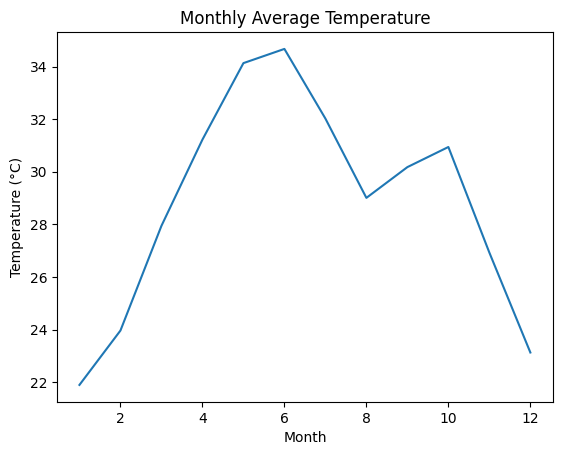

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

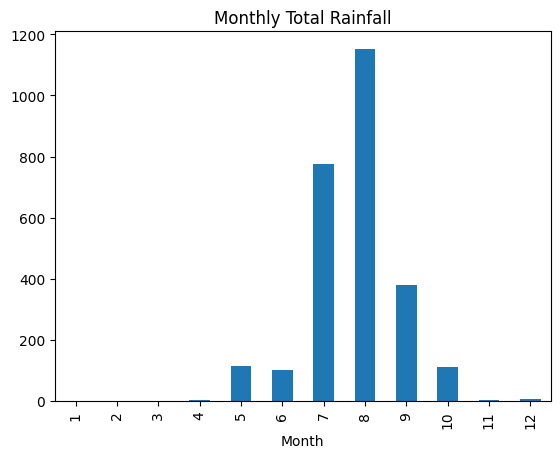

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Total Rainfall")
plt.show()

# 14. Correlation Heatmap
**Objective:** To identify the strength and direction of relationships between various meteorological variables to understand Sudan's Sahelian and arid climate dynamics.

**Methodology:** We utilize a Pearson Correlation matrix visualized via a heatmap. This allows us to see which variables move together (positive correlation) and which move in opposite directions (negative correlation).

**Key Insights from Sudan Dataset:**

**Temperature Coupling:** A very strong positive correlation exists between T2M and T2M_MAX (0.93) and an even stronger one with T2M_MIN (0.94). This confirms that Sudan's daily average temperatures are shifted upward by both extreme daytime peaks and high nighttime baselines, reflecting the intense thermal retention of its desert-edge environment.

**Relative Humidity & Temperature Range:** There is a very strong negative correlation (-0.81) between RH2M (Relative Humidity) and T2M_RANGE. This indicates that in the absence of moisture, the air loses its "thermal buffer," leading to the extreme diurnal temperature swings (up to 22.48°C) observed in the summary statistics.

**Specific Humidity & Moisture:** An almost perfect positive correlation (0.94) exists between RH2M and QV2M (Specific Humidity). In Sudan's arid context, this suggests that relative humidity is almost entirely dependent on the actual mass of water vapor present in the air, likely governed by the arrival of the seasonal monsoon.

**Wind Speed Dynamics:** WS2M and WS2M_MAX maintain a very high correlation (0.90), validating that wind patterns across the Sudanese plains are consistent and likely driven by large-scale pressure gradients rather than localized turbulence.

**Pressure & Temperature:** We observe an exceptionally strong negative correlation between PS (Surface Pressure) and temperature variables, reaching -0.87 for T2M and -0.84 for T2M_MAX. This reflects the intense thermal low-pressure systems that dominate Sudan during its hottest months, where rising hot air significantly lowers surface pressure.

**Conclusion for COP32:** For Sudan, the near-perfect coupling between specific humidity and relative humidity (0.94) coupled with the strong inverse relationship between pressure and heat (-0.87) highlights a high vulnerability to "Heat-Low" systems. Adaptation strategies must prioritize the monitoring of these thermal lows, as they are primary drivers of both extreme heatwaves and the rapid onset of the haboob (dust storm) season, which directly threatens regional air quality and agricultural stability.

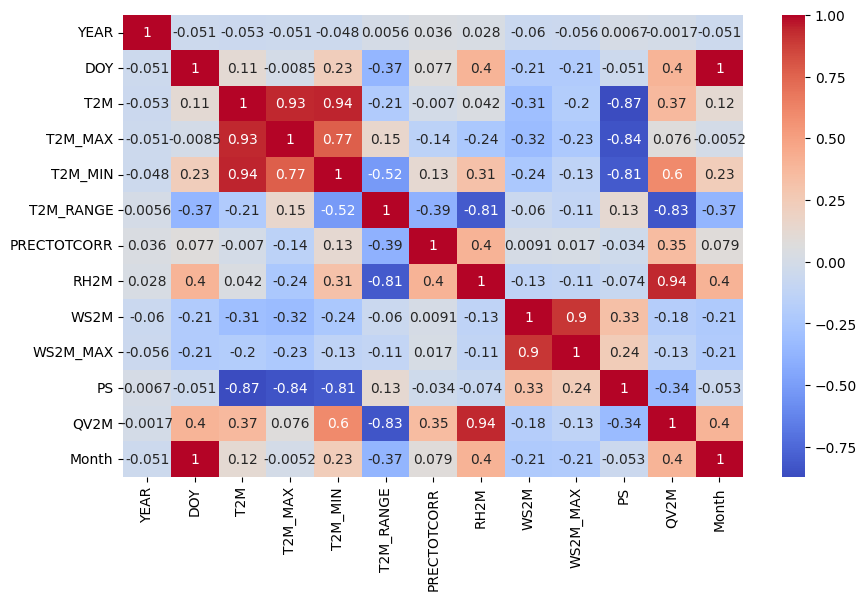

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# 15. Relationship Analysis (Scatter Plots)

**Objective:** To visualize the interactions between primary climate drivers and identify non-linear patterns or clusters within the Sudanese dataset.

**A. Temperature (T2M) vs. Relative Humidity (RH2M)**
**Interpretation:** This plot exhibits an extreme decoupling of heat and moisture, characteristic of a Sahelian-to-desert transition zone.

**Observations:** The data shows a massive cluster of low-humidity points across a wide temperature spectrum (20°C to 38°C). A distinct "hook" pattern is visible where humidity only spikes (reaching above 60%) when temperatures are moderated between 25°C and 30°C. This moderation is likely due to the cooling effect of the rainy season.

**Climate Context:** Unlike Kenya's linear path, Sudan’s atmosphere remains hyper-arid for the majority of the temperature range. Heat stress here is "dry" for most of the year, but the sudden influx of moisture during the monsoon (the "hook") creates high-humidity/high-heat conditions that significantly increase the wet-bulb temperature risk.

**B. Temperature Range (T2M_RANGE) vs. Wind Speed (WS2M)**

**Interpretation:** There is a broad, dense distribution indicating that high daily temperature fluctuations are a constant driver of wind activity across the Sudanese plains.

**Observations:** Sudan maintains a higher "floor" for wind speeds compared to Kenya, with the densest activity occurring between 2.0 and 5.0 m/s. Large temperature ranges (often exceeding 15°C) are frequently coupled with these sustained winds.

**Physical Context:** In Sudan, this relationship is a signature of thermal forcing. The extreme heating of the desert during the day creates intense pressure gradients. This relationship is a critical indicator for the development of dust storms (haboobs); as the temperature range expands on dry days, the resulting thermal winds are more likely to lift surface dust, impacting visibility and respiratory health across the region.

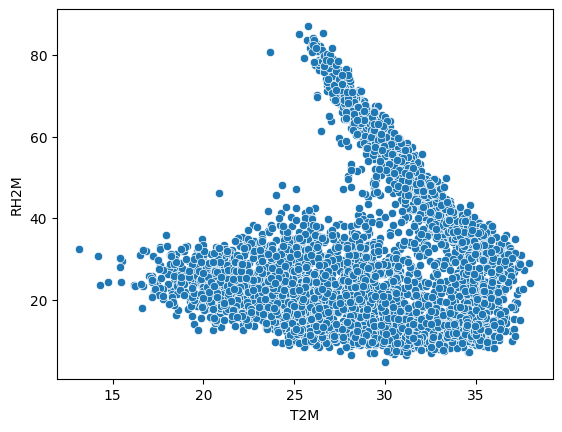

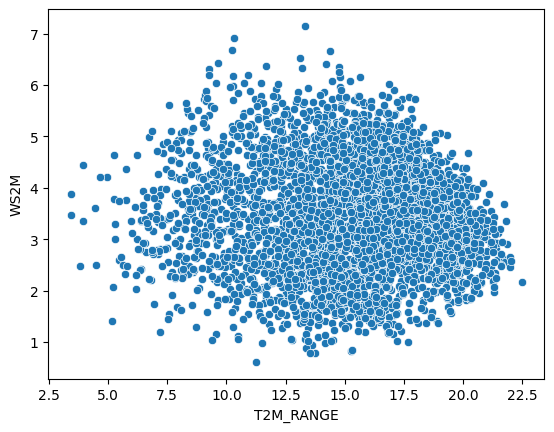

In [15]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

# 16. Distribution Analysis (Precipitation)

**Objective:** To analyze the frequency and intensity of rainfall events across Sudan to assess hydrological extremes, such as flash floods and prolonged dry spells.

**Methodology:** We utilized a histogram with a Kernel Density Estimate (KDE) and a logarithmic scale on the y-axis (Count) to capture the full spectrum of precipitation events.

**Interpretation:**
**Extreme Right-Skewed Distribution:** Sudan’s precipitation profile shows an even more pronounced right-skew than Kenya’s, with the overwhelming majority of the dataset concentrated at zero. This quantitatively confirms the hyper-arid nature of the region for most of the year.

**The "Log Scale" Insight:** By using a log scale, we can identify rare but catastrophic precipitation events that exceed 60 mm/day. While the frequency of any rain is low, when events do occur, they can be significantly more intense than the peaks seen in the Kenya dataset (which capped near 50 mm).

**Monsoonal Pulse:** The KDE curve remains relatively flat with minor oscillations before tapering off. This lack of distinct "bumps" suggests that rainfall in Sudan is less about steady seasonal patterns and more about erratic, high-intensity convective bursts typical of the Sahelian monsoon.

**Climate Resilience Note:** The extreme tail of the distribution, reaching above 65 mm, represents a severe flash-flood risk. Because the ground in arid regions like Sudan is often compacted and less absorbent, these high-intensity outliers—though infrequent—pose a greater threat to infrastructure and life than similar volumes would in more temperate, humid climates.

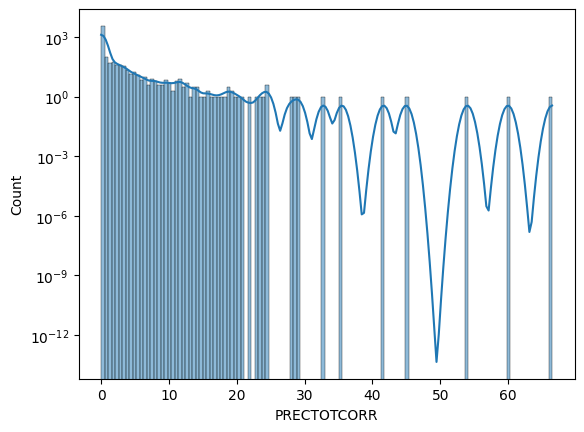

In [16]:
sns.histplot(df["PRECTOTCORR"], kde=True)
plt.yscale("log")
plt.show()

# 17. Multivariate Analysis (Bubble Chart)

**Objective:** To examine the three-way interaction between Temperature (T2M), Relative Humidity (RH2M), and Precipitation (PRECTOTCORR) to define Sudan's climatic "event envelope."

**Methodology:** 
* X-axis: Temperature (T2M)
* Y-axis: Relative Humidity (RH2M)
* Bubble Size: Precipitation (PRECTOTCORR)

**Interpretation:**
**Monsoonal Rainfall Corridor:**  In Sudan, the most intense rainfall events (largest bubbles) are sharply concentrated in a specific "thermal pocket" between 25°C and 30°C with humidity levels surging above 70%. This represents the core of the summer monsoon season where moisture-laden air provides a cooling effect on the extreme Sahelian heat.

**Hyper-Arid Dominance:** The chart is dominated by a vast field of small bubbles in the lower-right quadrant, where temperatures exceed 35°C and humidity stays below 30%. This highlights that Sudan’s most extreme heat occurs in almost total absence of rainfall, reinforcing the hyper-arid baseline identified in previous sections.

**Moisture-Temperature Decoupling:** There is a notable "gap" in the upper-right quadrant (High Temperature + High Humidity). This suggests that in Sudan, high atmospheric moisture and extreme heat (above 33°C) rarely coexist, as the presence of clouds and rain during the monsoon tends to suppress the peak surface temperatures.

**The Rainfall "Trigger":** The tight clustering of large bubbles only when temperatures drop below 30°C suggests a high threshold for effective precipitation. Rainfall in this region is not a gradual process but a sudden shift in atmospheric state once a specific moisture-to-temperature ratio is reached.


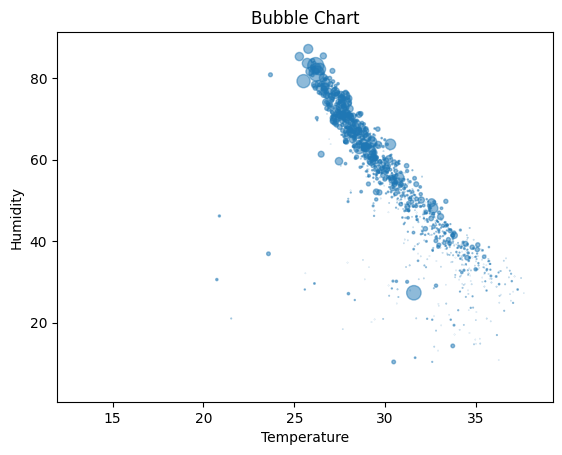

In [17]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart")
plt.show()